In [6]:
# Cell 1: Don't Edit This Cell
# --------------------------------------------------------------------------------------------------

# Import Libraries and Load Data

# --------------------------------------------------------------------------------------------------

# Import libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_curve, f1_score, auc, roc_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
data_root_dir = "./data"
# Read the test data set into a dataframe
X_test_unseen = pd.read_csv(f'{data_root_dir}/test.csv')

# Read the train data set into a dataframe
train_data = pd.read_csv(f'{data_root_dir}/train.csv')

# Separate the train data into a features and a response dataframe
X = train_data.drop(columns=['quality'])
y = train_data['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

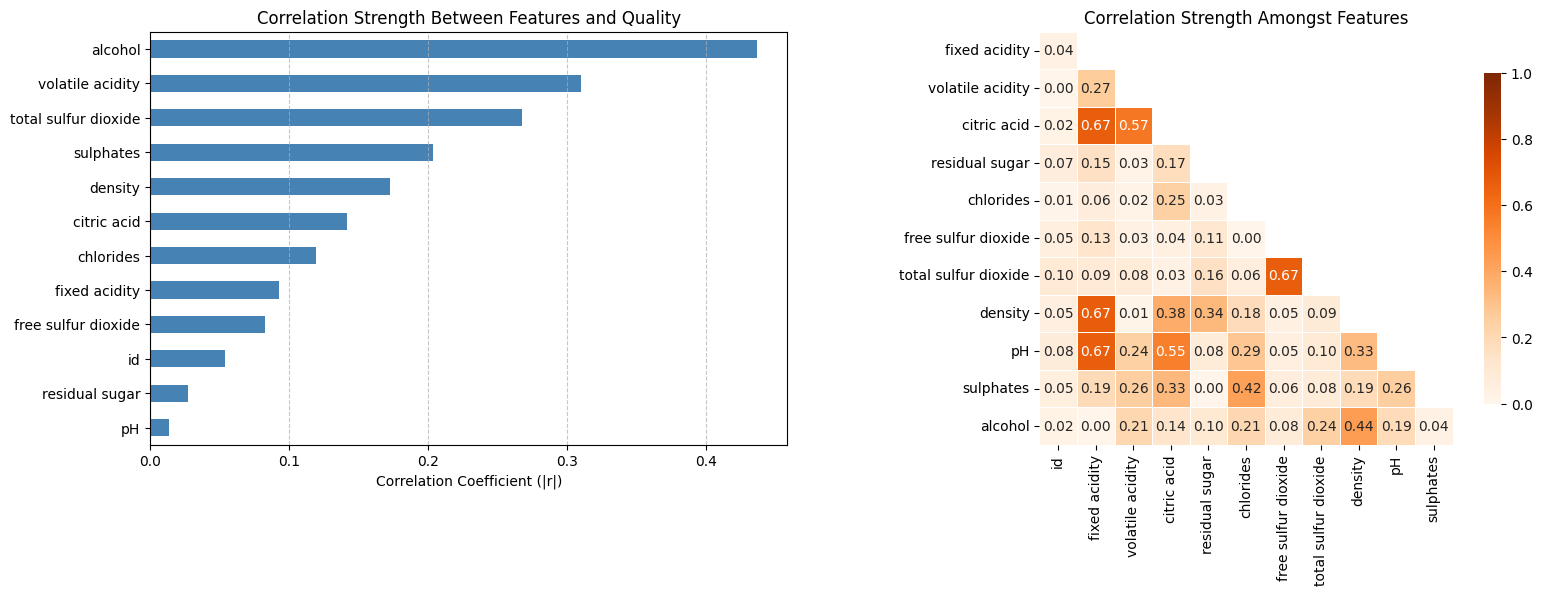

In [7]:
# Cell 2: Don't Edit This Cell
# --------------------------------------------------------------------------------------------------

# Basic Exploratory Data Analysis (EDA):
    # Review the correlation strength between each predictor and the response (Quality) using the bar chart
    # Review the correlation strength between each pair of features using the correlation matrix heat map

# --------------------------------------------------------------------------------------------------

# Compute correlation of predictors with 'quality'
correlations = train_data.corr()['quality'].drop('quality')

# Compute absolute correlation matrix amongst predictors
corr_matrix = X_train.corr().abs()

# Create a mask for the upper triangle
full_mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
mask_df = pd.DataFrame(full_mask, index=corr_matrix.index, columns=corr_matrix.columns)

# Drop 'id' row and 'alcohol' column from both corr matrix and mask
corr_matrix = corr_matrix.drop(index='id', columns='alcohol', errors='ignore')
mask_df = mask_df.drop(index='id', columns='alcohol', errors='ignore')

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of correlations with quality
correlations.abs().sort_values().plot(kind='barh', color='steelblue', ax=ax1)
ax1.set_title('Correlation Strength Between Features and Quality')
ax1.set_xlabel('Correlation Coefficient (|r|)')
ax1.grid(True, axis='x', linestyle='--', alpha=0.7)

# Heatmap of absolute correlation matrix (lower triangle only)
sns.heatmap(corr_matrix, mask=mask_df, annot=True, fmt=".2f", cmap="Oranges",
            vmin=0, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax2)
ax2.set_title('Correlation Strength Amongst Features')

plt.tight_layout()
plt.show()

In [8]:
# Cell 3: Edit This Cell
# --------------------------------------------------------------------------------------------------

# Edit the list 'selected_features' to include only the features you want included in the model
# Type a '#' to the left of any features you want to remove.
# Consider using the above visuals to decide which you want to include:
    # In general, it's good to include features that correlate highly with the response (Quality)
    # In general, it's not good to include 2 or more features that correlate highly with eachother, even if they all individually correlate with the response.

# Note, 'id' values are unique numbers arbitrarily assigned to the records.  Any correlation with other variables, including the response, is spurious.
# 'id' is typically not included when modeling, but it is up to you.

# --------------------------------------------------------------------------------------------------

selected_features = [
                        #'id',
                        'fixed acidity',
                        'volatile acidity',
                        'citric acid',
                        'residual sugar',
                        'chlorides',
                        'free sulfur dioxide',
                        'total sulfur dioxide',
                        'density',
                        'pH',
                        'sulphates',
                        'alcohol'
                    ]

In [9]:
# Cell 4: Don't Edit This Cell
# --------------------------------------------------------------------------------------------------

# Create train and test feature sets that only include the selected features

# --------------------------------------------------------------------------------------------------

X_train_selected = X_train[selected_features]
X_test_ids = X_test['id']
X_test_selected = X_test[selected_features]

In [10]:
# Cell 5: Don't Edit This Cell
# --------------------------------------------------------------------------------------------------

# Train a logistic regression model using the training data responses and the selected features

# --------------------------------------------------------------------------------------------------

model = LogisticRegression(max_iter=1000)
model.fit(X_train_selected, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Optimal Threshold (maximizing F1-score) on training data: 0.4255


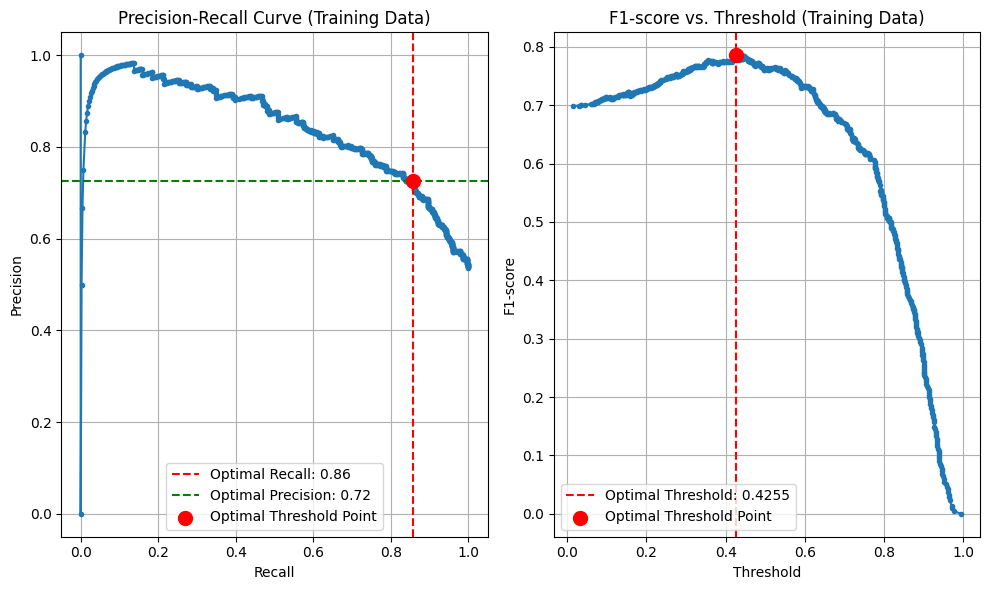

In [11]:
# Cell 6: Edit This Cell
# --------------------------------------------------------------------------------------------------

# Edit the variable 'threshold' with a classification threshold.  The logistic regression model calculates the probability that a given wine is 1 (Good).
    # If this probability is greater than the threshold, it will be classified as 1 (Good)
    # If this probability is less than the threshold, it will be classified as 0 (Bad)

# --------------------------------------------------------------------------------------------------


# 3. Get predicted probabilities on the TRAINING data
# It's crucial to use TRAINING data for threshold optimization to avoid data leakage
y_train_pred_proba = model.predict_proba(X_train_selected)[:, 1] # Probability of the positive class

# 4. Compute Precision-Recall Curve
# The precision_recall_curve function returns precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_train, y_train_pred_proba)

# 5. Find the optimal threshold based on F1-score
# We iterate through the thresholds and calculate the F1-score for each.
# Note: The last threshold returned by precision_recall_curve is 1.0, and has corresponding
# precision and recall values. To avoid issues with division by zero or empty predictions,
# it's common to iterate up to len(thresholds)-1.
f1_scores = []
for i in range(len(thresholds)):
    # Handle the case where precision + recall is zero to avoid division by zero
    if (precision[i] + recall[i]) == 0:
        f1_scores.append(0)
    else:
        f1 = 2 * (precision[i] * recall[i]) / (precision[i] + recall[i])
        f1_scores.append(f1)

optimal_threshold_idx = np.argmax(f1_scores)
optimal_threshold_f1 = thresholds[optimal_threshold_idx]

print(f"Optimal Threshold (maximizing F1-score) on training data: {optimal_threshold_f1:.4f}")

# Optional: Visualize the Precision-Recall curve and F1-score
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Training Data)')
plt.grid(True)
plt.axvline(x=recall[optimal_threshold_idx], color='r', linestyle='--', label=f'Optimal Recall: {recall[optimal_threshold_idx]:.2f}')
plt.axhline(y=precision[optimal_threshold_idx], color='g', linestyle='--', label=f'Optimal Precision: {precision[optimal_threshold_idx]:.2f}')
plt.scatter(recall[optimal_threshold_idx], precision[optimal_threshold_idx], color='red', s=100, zorder=5, label='Optimal Threshold Point')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(thresholds, f1_scores, marker='.')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs. Threshold (Training Data)')
plt.grid(True)
plt.axvline(x=optimal_threshold_f1, color='red', linestyle='--', label=f'Optimal Threshold: {optimal_threshold_f1:.4f}')
plt.scatter(optimal_threshold_f1, f1_scores[optimal_threshold_idx], color='red', s=100, zorder=5, label='Optimal Threshold Point')
plt.legend()

plt.tight_layout()
plt.show()


threshold = optimal_threshold_f1

In [15]:
# 6. Evaluate classifier with the optimal threshold on the test set
y_test_pred_proba = model.predict_proba(X_test_selected)[:, 1]
y_test_pred_optimal = (y_test_pred_proba >= optimal_threshold_f1).astype(int)

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("\n--- Evaluation on Test Data with Optimal Threshold ---")
print(f"Optimal Threshold: {optimal_threshold_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_optimal))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_optimal))
print(f"Accuracy Score: {accuracy_score(y_test, y_test_pred_optimal):.4f}")


--- Evaluation on Test Data with Optimal Threshold ---
Optimal Threshold: 0.4255

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.66      0.72       155
           1       0.74      0.83      0.79       181

    accuracy                           0.76       336
   macro avg       0.76      0.75      0.75       336
weighted avg       0.76      0.76      0.75       336

Confusion Matrix:
[[103  52]
 [ 30 151]]
Accuracy Score: 0.7560


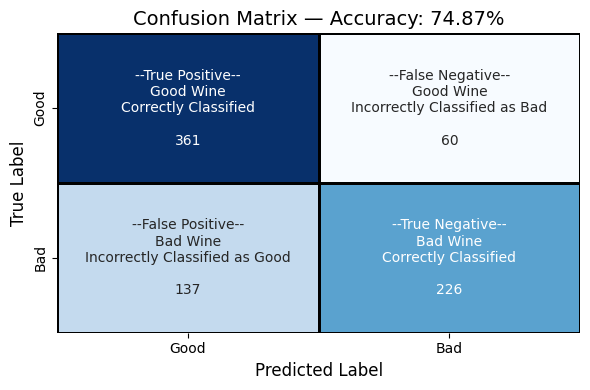

In [12]:
# Cell 7: Don't Edit This Cell
# --------------------------------------------------------------------------------------------------

# Evaluate your model's performance with a confusion matrix.
# It compares the true quality of every wine in the training data, with your model's prediction.
# The overall accuracy of the model is in the title of the matrix.
# Note, submission scores will typically be a lower than the accuracy exhibited by your training data.
# Consider experimenting with different features in cell 3 and different thresholds in cell 6, and observe how the performance changes.

# --------------------------------------------------------------------------------------------------

# Predictions

train_probability_predictions = model.predict_proba(X_train_selected)[:, 1]
train_class_predictions = [1 if x >= threshold else 0 for x in train_probability_predictions]

# Confusion matrix and accuracy
cm = confusion_matrix(y_train, train_class_predictions, labels=[1, 0])
acc = accuracy_score(y_train, train_class_predictions)

# Labels for heatmap
annot_labels = np.array([
    [f"--True Positive--\nGood Wine\nCorrectly Classified\n\n{cm[0,0]}",
     f"--False Negative--\nGood Wine\nIncorrectly Classified as Bad\n\n{cm[0,1]}"],
    [f"--False Positive--\nBad Wine\nIncorrectly Classified as Good\n\n{cm[1,0]}",
     f"--True Negative--\nBad Wine\nCorrectly Classified\n\n{cm[1,1]}"]
])

# Create smaller figure
plt.figure(figsize=(6, 4))  # smaller overall footprint

# Plot with black borders
sns.heatmap(cm, annot=annot_labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=["Good", "Bad"], yticklabels=["Good", "Bad"],
            annot_kws={"fontsize": 10},
            linecolor='black', linewidths=1)  # black cell borders

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title(f"Confusion Matrix — Accuracy: {acc:.2%}", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Cell 8: Don't Edit This Cell
# --------------------------------------------------------------------------------------------------

# Use your model to calculate predictions for the wines in the test data, and create a submission file.

# --------------------------------------------------------------------------------------------------

# Calculate predictions for test records
test_probability_predictions = model.predict_proba(X_test_selected)[:,1]
test_class_predictions = [1 if x >= threshold else 0 for x in test_probability_predictions]

# Combine record id and predictions into one dataframe
submission = pd.DataFrame()
submission['id'] = X_test_ids
submission['quality'] = test_class_predictions

# Output predictions to a csv for submission
submission.to_csv('submission.csv', index=False)

In [34]:
y_train_pred_proba

array([[0.02497218, 0.97502782],
       [0.57912297, 0.42087703],
       [0.40421428, 0.59578572],
       ...,
       [0.48733636, 0.51266364],
       [0.60492786, 0.39507214],
       [0.20223653, 0.79776347]], shape=(1120, 2))